In [1]:
# For mounting Google Drive in Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import pandas as pd

In [3]:
# data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DL-A-and-M-project/dlam-ts-project-data-2026/train.csv')
data=pd.read_csv('../Data/train.csv')

In [4]:
data.head(10)

,series_id,timestamp,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,trend,workload_intensity,demand_forecast,...,unit_reliability_forecast,queue_pressure_forecast,network_pressure_forecast,event_load_forecast,service_irregularity_risk_forecast,throughput_disruption_risk_forecast,nominal_capacity,zone_sin,zone_cos,target
0,unit_000,2023-01-01 00:00:00,0.000000,1.000000e+00,-0.781831,0.62349,1.0,-1.731704,0.001633,0.027929,...,1.000000,1.768614,0.818472,0.160134,0.000000,0.063503,82.690278,0.0,1.0,2.989556
1,unit_000,2023-01-01 01:00:00,0.258819,9.659258e-01,-0.781831,0.62349,1.0,-1.731010,0.004694,0.000000,...,0.887202,1.806212,1.816860,0.004240,0.080810,0.000000,82.690278,0.0,1.0,3.199527
2,unit_000,2023-01-01 02:00:00,0.500000,8.660254e-01,-0.781831,0.62349,1.0,-1.730316,0.012069,0.110750,...,0.986113,NaN,2.596726,0.208973,0.000000,0.009573,82.690278,0.0,1.0,3.425670
3,unit_000,2023-01-01 03:00:00,0.707107,7.071068e-01,-0.781831,0.62349,1.0,-1.729622,0.027770,0.164394,...,0.969943,2.778944,1.857860,0.241452,0.064186,0.000000,82.690278,0.0,1.0,3.133322
4,unit_000,2023-01-01 04:00:00,0.866025,5.000000e-01,-0.781831,0.62349,1.0,-1.728928,0.057179,0.000000,...,0.901797,1.156086,2.489084,0.000000,0.000000,0.017581,82.690278,0.0,1.0,2.535954
5,unit_000,2023-01-01 05:00:00,0.965926,2.588190e-01,-0.781831,0.62349,1.0,-1.728234,0.105351,0.000000,...,0.723841,2.480163,1.497353,0.000000,0.000000,0.000452,82.690278,0.0,1.0,3.731474
6,unit_000,2023-01-01 06:00:00,1.000000,6.123234e-17,-0.781831,0.62349,1.0,-1.727540,0.173695,0.000000,...,0.961783,5.053993,2.810370,0.025339,0.000000,0.000000,82.690278,0.0,1.0,4.711265
7,unit_000,2023-01-01 07:00:00,0.965926,-2.588190e-01,-0.781831,0.62349,1.0,-1.726846,0.256259,0.000000,...,0.934618,NaN,3.709222,0.036630,0.194124,0.000000,82.690278,0.0,1.0,6.025582
8,unit_000,2023-01-01 08:00:00,0.866025,-5.000000e-01,-0.781831,0.62349,1.0,-1.726152,0.338314,0.000000,...,1.000000,8.515514,5.006930,0.000000,0.000000,0.000958,82.690278,0.0,1.0,7.333437
9,unit_000,2023-01-01 09:00:00,0.707107,-7.071068e-01,-0.781831,0.62349,1.0,-1.725459,0.399690,0.000000,...,0.971799,9.581625,7.099066,0.030685,0.026113,0.094069,82.690278,0.0,1.0,8.395303


### Training data shape: (414720, 25)

# Extracts the info of each column
1.   No of non null values
2.   And data type of each column
3.   Numbers of unique values in each features
4.   Finally overall description of each column (Mean, Standard deviation, Minimum, Maximum, )

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 414720 entries, 0 to 414719
Data columns (total 25 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   series_id                            414720 non-null  str    
 1   timestamp                            414720 non-null  str    
 2   hour_sin                             414720 non-null  float64
 3   hour_cos                             414720 non-null  float64
 4   dow_sin                              414720 non-null  float64
 5   dow_cos                              414720 non-null  float64
 6   is_weekend                           414720 non-null  float64
 7   trend                                414720 non-null  float64
 8   workload_intensity                   414720 non-null  float64
 9   demand_forecast                      396158 non-null  float64
 10  staffing_forecast                    396089 non-null  float64
 11  upstream_quality_forecas

In [6]:
data.nunique()

series_id                                  96
timestamp                                4320
hour_sin                                   21
hour_cos                                   22
dow_sin                                     7
dow_cos                                     7
is_weekend                                  2
trend                                    4320
workload_intensity                         48
demand_forecast                          2868
staffing_forecast                        4320
upstream_quality_forecast                2747
promotion_intensity                        31
shock_risk                             347754
maintenance_known                         457
unit_reliability_forecast              368048
queue_pressure_forecast                377444
network_pressure_forecast              391081
event_load_forecast                    325516
service_irregularity_risk_forecast     305165
throughput_disruption_risk_forecast    230924
nominal_capacity                  

In [7]:
data.describe()

,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,trend,workload_intensity,demand_forecast,staffing_forecast,upstream_quality_forecast,...,unit_reliability_forecast,queue_pressure_forecast,network_pressure_forecast,event_load_forecast,service_irregularity_risk_forecast,throughput_disruption_risk_forecast,nominal_capacity,zone_sin,zone_cos,target
count,4.147200e+05,4.147200e+05,414720.000000,414720.000000,414720.000000,414720.000000,414720.000000,396158.000000,396089.000000,395946.000000,...,396233.000000,396182.000000,396027.000000,395953.000000,396025.000000,396119.000000,414720.000000,4.147200e+05,4.147200e+05,414720.000000
mean,-1.836665e-17,-5.647060e-17,0.007827,0.006242,0.283333,-0.233161,0.396516,0.233164,0.004956,0.947024,...,0.887990,5.078827,5.069581,0.684237,0.090117,0.037429,71.042672,1.754427e-17,-5.263280e-17,9.912838
std,7.071076e-01,7.071076e-01,0.706519,0.707625,0.450617,0.865386,0.286319,0.338579,0.997847,0.073080,...,0.071463,3.542780,3.033168,0.906629,0.096764,0.060459,9.730984,7.071076e-01,7.071076e-01,5.548231
min,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969,0.000000,-1.731704,0.001633,0.000000,-2.643780,0.406849,...,0.511181,0.000000,0.000000,0.000000,0.000000,0.000000,56.201276,-1.000000e+00,-1.000000e+00,0.164003
25%,-7.071068e-01,-7.071068e-01,-0.781831,-0.900969,0.000000,-0.982432,0.162079,0.000000,-0.761032,0.918763,...,0.840032,2.342134,2.736273,0.052000,0.005970,0.000000,61.362290,-7.071068e-01,-7.071068e-01,5.801159
50%,6.123234e-17,-6.123234e-17,0.000000,-0.222521,0.000000,-0.233161,0.394245,0.109282,0.001070,0.975669,...,0.891391,4.707812,4.830087,0.286588,0.068168,0.013264,70.514341,6.123234e-17,-6.123234e-17,9.041956
75%,7.071068e-01,7.071068e-01,0.781831,0.623490,1.000000,0.516111,0.614908,0.330736,0.775085,1.000000,...,0.941789,7.315502,7.085276,0.982119,0.135696,0.056647,80.595938,7.071068e-01,7.071068e-01,13.025928
max,1.000000e+00,1.000000e+00,0.974928,1.000000,1.000000,1.265382,1.057221,2.818878,2.581451,1.000000,...,1.000000,24.751646,19.151923,6.953740,1.000000,0.765789,85.974279,1.000000e+00,1.000000e+00,53.000163


# Finding out the number of Missing data entries in each columns, if any

In [8]:
ser = data.isna().mean()*100
ser = ser[ser!=0]
print(ser)

demand_forecast                        4.475791
staffing_forecast                      4.492429
upstream_quality_forecast              4.526910
shock_risk                             4.560667
unit_reliability_forecast              4.457706
queue_pressure_forecast                4.470004
network_pressure_forecast              4.507378
event_load_forecast                    4.525222
service_irregularity_risk_forecast     4.507861
throughput_disruption_risk_forecast    4.485195
dtype: float64


In [9]:
print("No of colums that have missing values", ser.size)

No of colums that have missing values 10


In [10]:
ser.keys()

Index(['demand_forecast', 'staffing_forecast', 'upstream_quality_forecast',
       'shock_risk', 'unit_reliability_forecast', 'queue_pressure_forecast',
       'network_pressure_forecast', 'event_load_forecast',
       'service_irregularity_risk_forecast',
       'throughput_disruption_risk_forecast'],
      dtype='str')

So here we have total 10 columns with missing values

# Finding out the number of duplicate rows

In [11]:
print(data.duplicated().sum())

0


Which means we don't have any duplicate rows

# We will plot time series graph to observe general trend in each functional unit.

In [12]:
import matplotlib.pyplot as plt

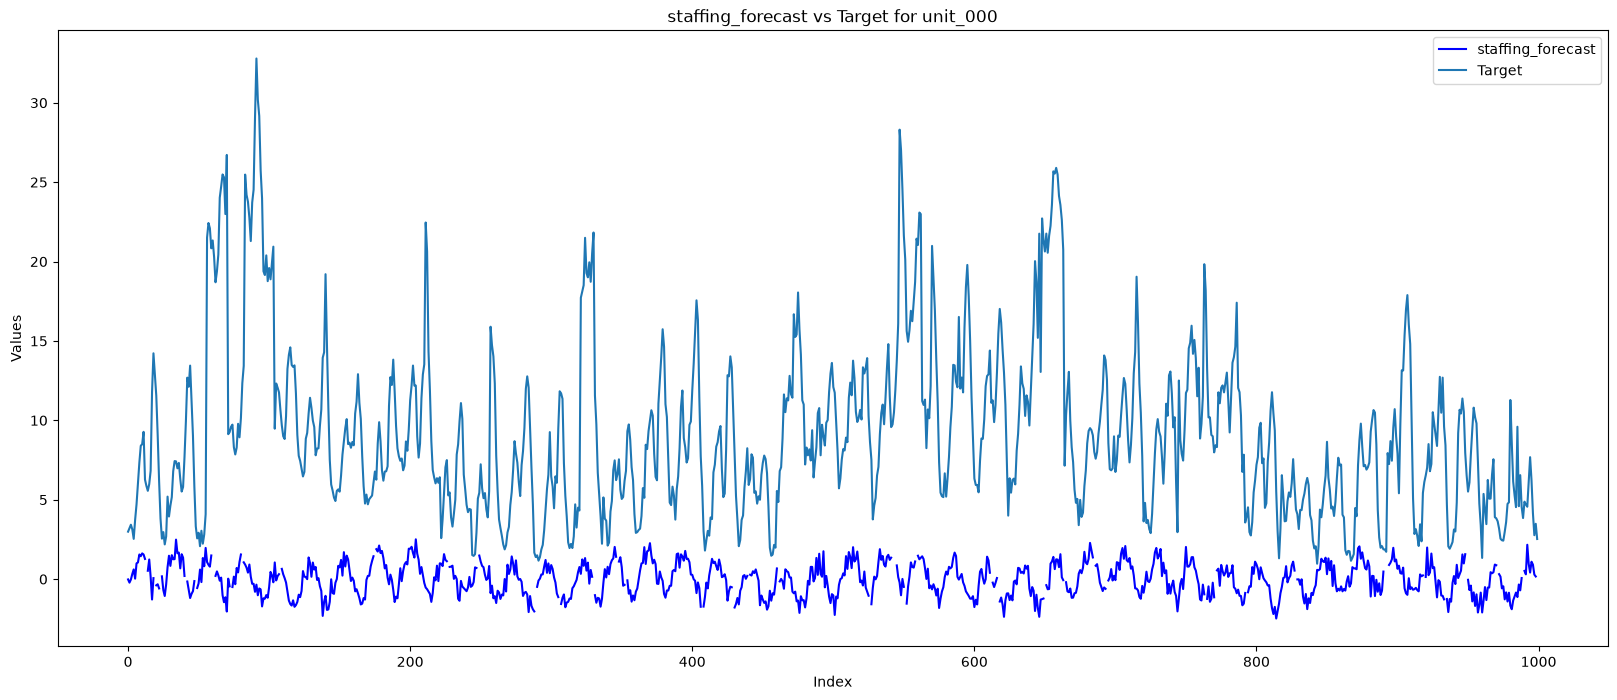

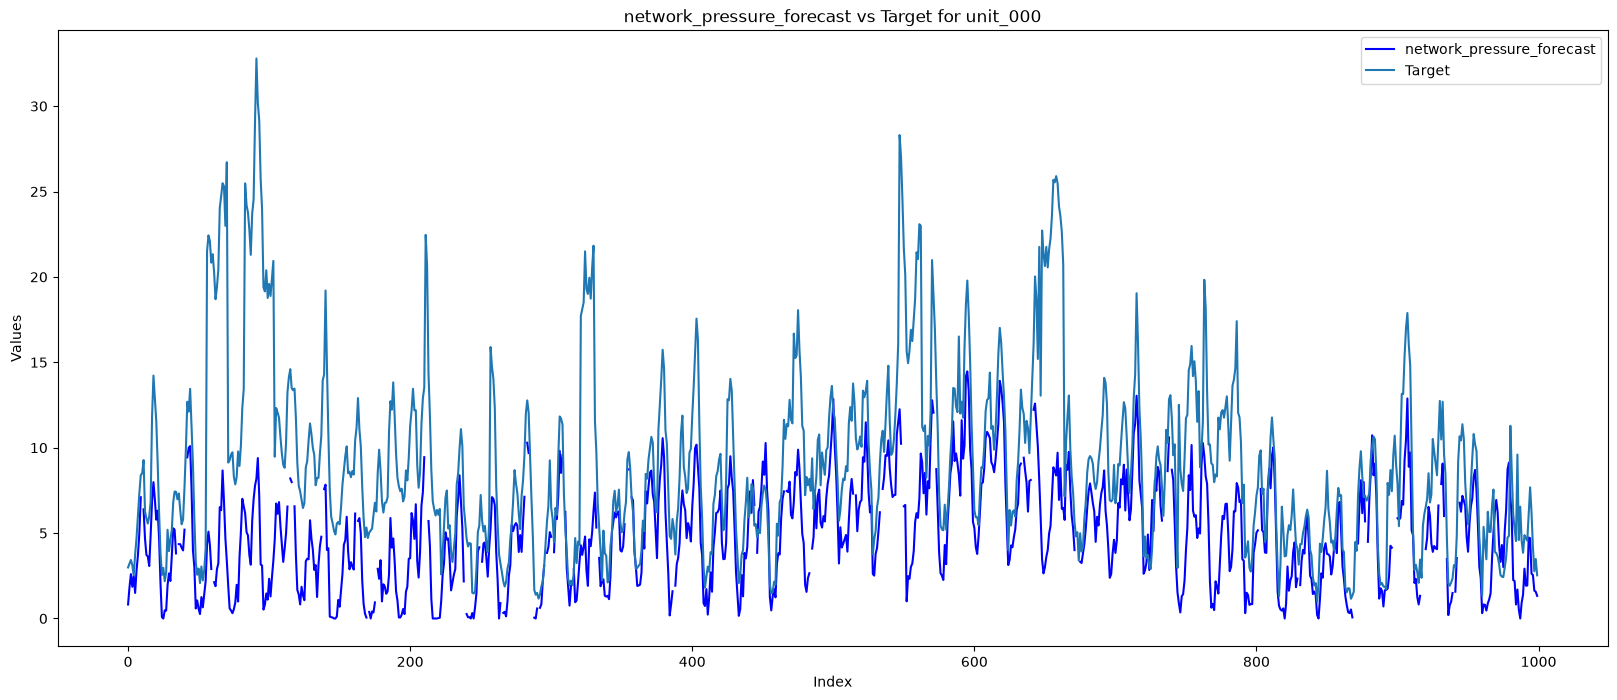

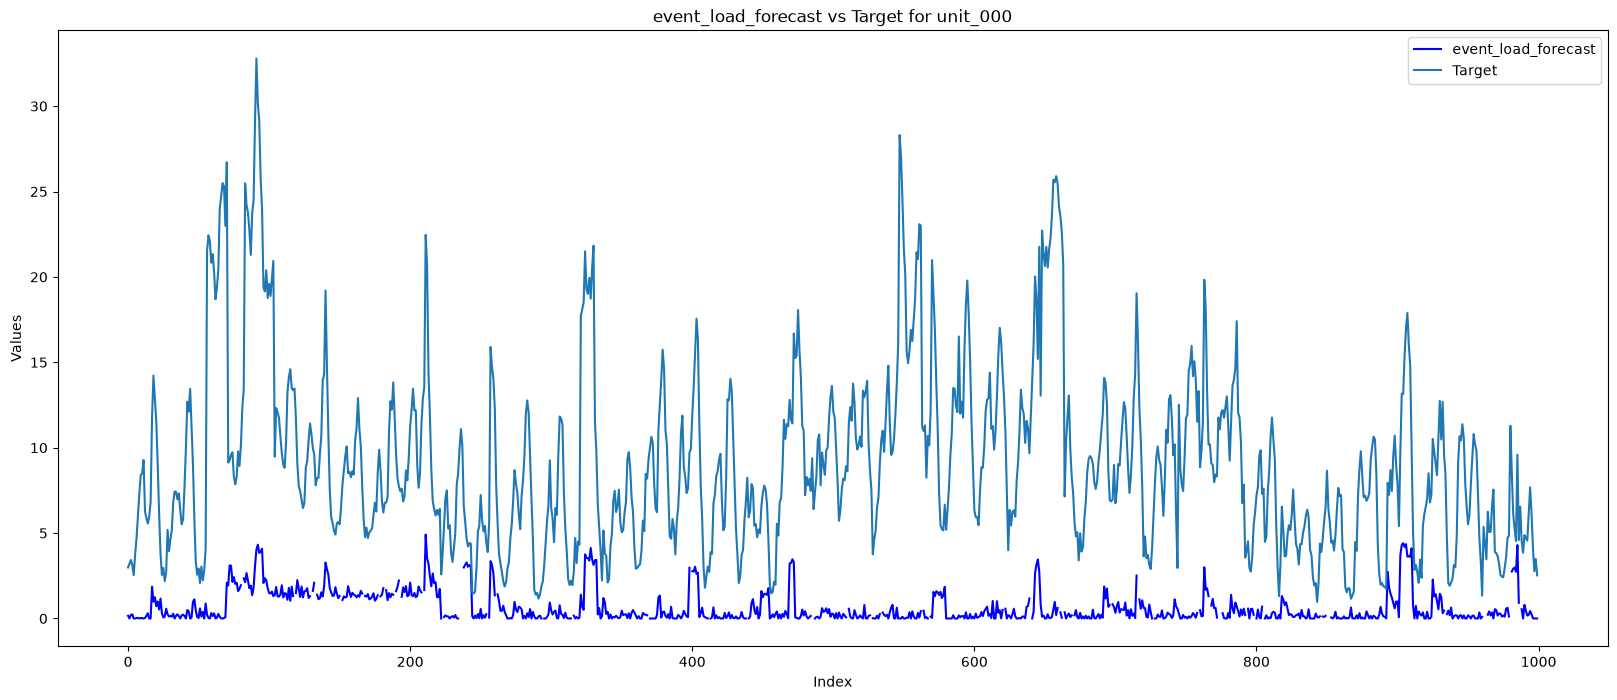

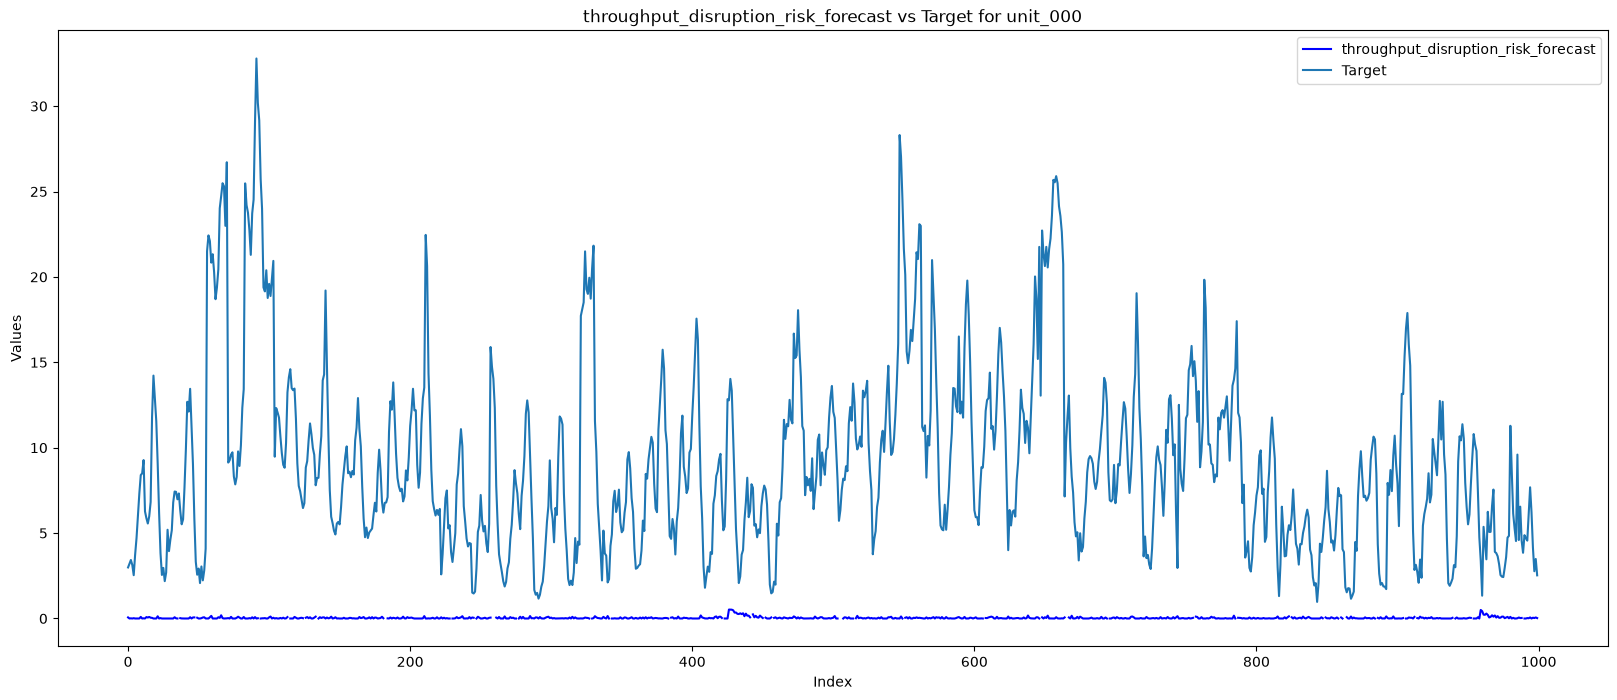

In [13]:
# 1. Filter for the specific unit
df_unit0 = data[data['series_id'] == "unit_000"]

# 2. Loop through the random columns and plot them against the target
columns_to_plot = ['staffing_forecast', 'network_pressure_forecast', 'event_load_forecast', 'throughput_disruption_risk_forecast']

for col in columns_to_plot:
    plt.figure(figsize=(20, 8)) # Keeps plots organized and safely separated

    # Plot the feature
    df_subset = df_unit0.iloc[:1000]
    plt.plot(df_subset.index, df_subset[col].to_numpy(), label=col, color='blue')

    # Plot the target on the same plot for comparison
    plt.plot(df_subset.index, df_subset['target'].to_numpy(), label='Target', linestyle='-')

    plt.title(f"{col} vs Target for unit_000")
    plt.xlabel("Index")
    plt.ylabel("Values")
    plt.legend()
    plt.show()

In [14]:
import json

with open('../Data/metadata.json', 'r') as file:
    matadata = json.load(file)

print(json.dumps(matadata, indent=4))

{
    "name": "operations_forecasting_2026",
    "task": "Multivariate hourly forecasting for anonymized operations units.",
    "target_column": "target",
    "target_description": "Predict the future hourly operational load index for each series_id. Higher values indicate more operational pressure in that unit.",
    "frequency": "h",
    "n_series": 96,
    "n_steps": 4992,
    "history_length": 168,
    "forecast_horizon": 24,
    "forecast_horizon_note": "Rollout block length. Submissions must still predict every row in the provided forecast_index_*.csv files.",
    "validation_horizon": 336,
    "test_horizon": 336,
    "required_prediction_horizon": {
        "validation": 336,
        "test": 336
    },
    "metric": "wape",
    "schema": {
        "train": [
            "series_id",
            "timestamp",
            "hour_sin",
            "hour_cos",
            "dow_sin",
            "dow_cos",
            "is_weekend",
            "trend",
            "workload_intensity

# Possible different data imputation techniques to fill the missing values.


* ##  Traditional imputation methods


1.   Forward fill (use last known data point to impute missing value.)
2.   Backward fill (we don't want our algorithm to see future data points)
3.   Linear interpolation (streight line b/w last known and next known value)
4.   Polinomial interpolation (fits a curved line through surrounding data points)


* ##  Advanced ML approaches


1.   Multivariate Imputation by Chained Equations (MICE)
2.   K-Nearest Neighbors (KNN) for Time Series
3.   Recurrent Neural Networks (RNNs)


* ##  Time-Series Specific Imputation


1.   Seasonal Decomposition
2.   Autoregressive Integrated Moving Average (ARIMA)



In [15]:
### Here we are using the forward fill method to fill the missing values in the dataset. This method fills the missing values with the last known value in the column. If there is no known value before the missing value, it fills with the first known value in the column. (To avoid data leakage, we are not using the backward or linear interpolation.)

# ## Linear interpolation
# data = data.infer_objects(copy=False)
# data.interpolate(method="linear", limit_direction="both", axis=0, inplace=True)


for features in ser.keys():
  # 1. Linear interpolate only internal gaps (where both past and future are known)
  data[features] = data.groupby('series_id')[features].transform(
      lambda g: g.interpolate(method='linear', limit_direction='forward')
  )

  # 2. Handle boundary gaps explicitly if any remain at the start
  data[features] = data.groupby('series_id')[features].transform(
      lambda g: g.bfill()
  )

In [16]:
ser = data.isna().mean()*100
ser = ser[ser!=0]
print(ser)

Series([], dtype: float64)


In [17]:
print("No of colums that remained with empty value", ser.size)

No of colums that remained with empty value 0


## Splitting all the units in train and test dataset (80-20 ratio).

In [18]:
train_list=[]
test_list=[]

for unit_id, group in data.groupby('series_id'):

    split_idx = int(len(group) * 0.8)

    train_unit = group.iloc[:split_idx]
    test_unit = group.iloc[split_idx:]

    train_list.append(train_unit)  #_> A list of different unit's dataframes
    test_list.append(test_unit)    #`>


train_df=pd.concat(train_list,ignore_index=True)
test_df=pd.concat(test_list,ignore_index=True)


In [19]:
train_df.shape

(331776, 25)

In [20]:
test_df.shape

(82944, 25)

### Creating separate files for simplicity.

In [21]:
from pathlib import Path
# filepath = Path("/content/drive/MyDrive/Colab Notebooks/DL-A-and-M-project/j_notebooks/MyData/train_df.csv")
filepath = Path("../Artifacts/train_df.csv")
filepath.parent.mkdir(parents=True, exist_ok=True)
train_df.to_csv(filepath, index=False)

In [22]:
# filepath = Path("/content/drive/MyDrive/Colab Notebooks/DL-A-and-M-project/j_notebooks/MyData/test_df.csv")
filepath = Path("../Artifacts/test_df.csv")
filepath.parent.mkdir(parents=True, exist_ok=True)
test_df.to_csv(filepath, index=False)